# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [118]:
# Import the library
import cv2
import numpy as np
from PIL import Image, ImageOps
from skimage import data
import matplotlib.pyplot as plt
import IPython.display as display

%matplotlib inline

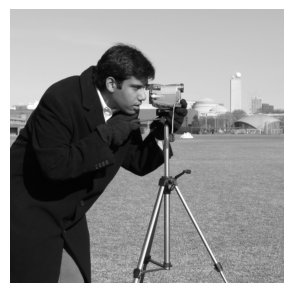

In [119]:
# ── Load image ────────────────────────────────────
image = Image.fromarray(data.camera())

plot_images(image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [120]:
# Get the size of the image

w, h = image.size
print(f"Image size: {w} x {h}")

# scaling factors
X=2
Y=2

Image size: 512 x 512


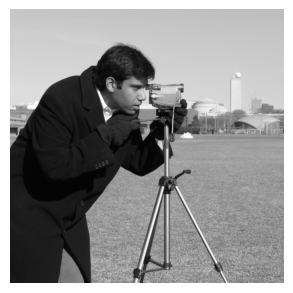

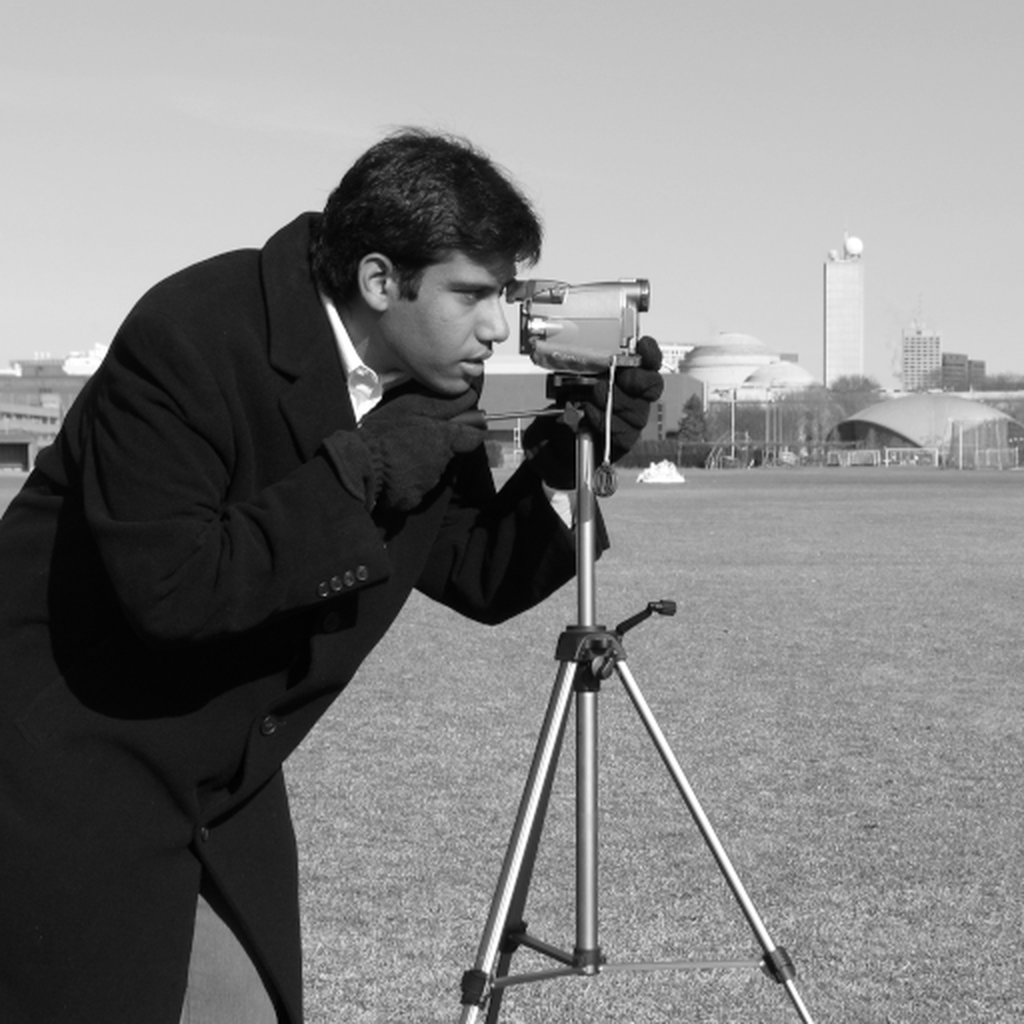

In [121]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scalImg = image.resize((w*X, h*Y), Image.LANCZOS)
plot_images(scalImg)
display.display(scalImg)

In [122]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scalImg.save("task1_1_scaled.jpg")
print(f"New image size: {scalImg.size}")

New image size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [123]:
w,h = image.size
cx= 2
cy= 1

In [124]:
non_uniImg = image.resize((w*cx, h*cy), Image.LANCZOS)

New image size: (1024, 512)


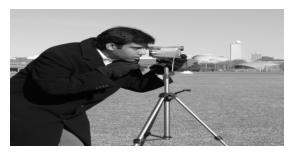

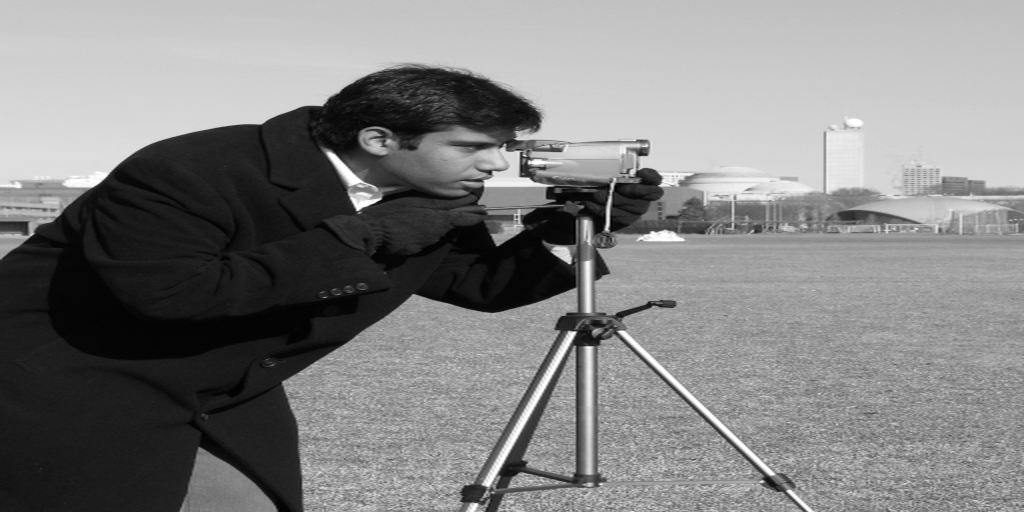

In [125]:
non_uniImg.save("task1_1_1_non-uni.jpg")
print(f"New image size: {non_uniImg.size}")
plot_images(non_uniImg)
display.display(non_uniImg)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

New image size: (512, 512)


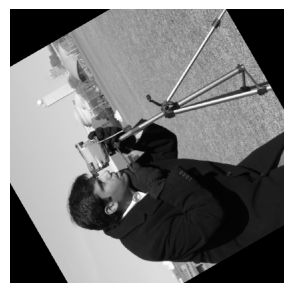

In [126]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotImg = image.rotate(120)
rotImg.save("task1_2_rotated.jpg")
print(f"New image size: {rotImg.size}")
plot_images(rotImg)

### 3. Shear

In [127]:
# -- c. Get the image dimensions ────────────────────
w, h = image.size

In [128]:
# -- d. define the shear matrix ──────────────────────────

shear_factor = 0.5

# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

new_w = int(w + (h * shear_factor))

In [129]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

shearM = (1, shear_factor, 0, 0, 1, 0)

shearedImg = image.transform((new_w, h), Image.AFFINE, shearM, resample=Image.Resampling.BICUBIC )

New image size: (768, 512)


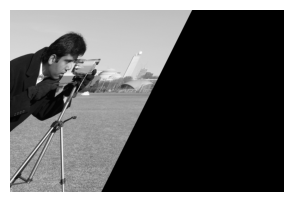

In [130]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")

shearedImg.save("task1_3_sheared.jpg")
print(f"New image size: {shearedImg.size}")
plot_images(shearedImg)

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

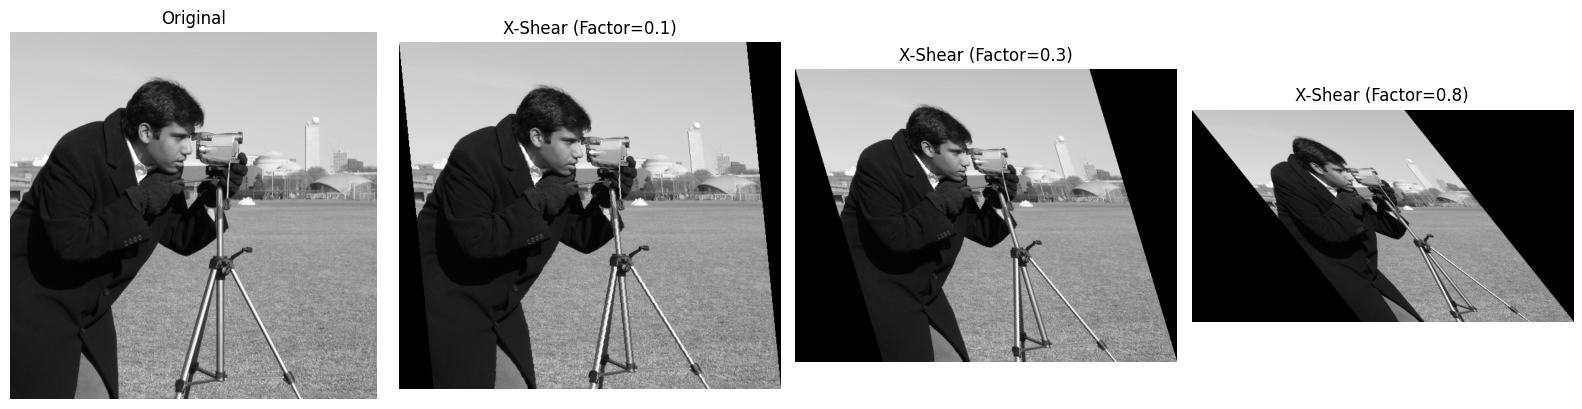

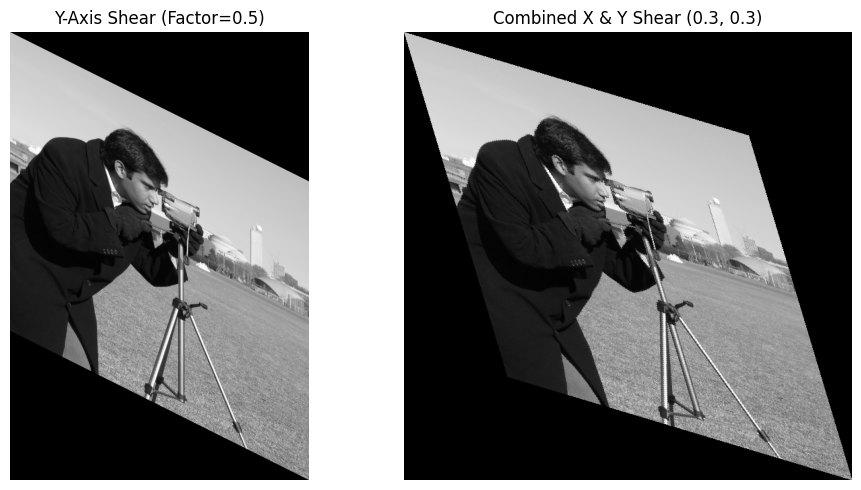

In [131]:
# Load the original image
img = Image.fromarray(data.camera())
width, height = img.size

shear_factors = [0.1, 0.3, 0.8]
fig1, axes1 = plt.subplots(1, 4, figsize=(16, 4))

axes1[0].imshow(img, cmap='gray')
axes1[0].set_title("Original")
axes1[0].axis('off')

for i, shx in enumerate(shear_factors):
    new_w = int(width + (height * shx))

    x_matrix = (1, -shx, 0, 0, 1, 0)

    sheared_img = img.transform((new_w, height), Image.AFFINE, x_matrix)
    axes1[i+1].imshow(sheared_img, cmap='gray')
    axes1[i+1].set_title(f"X-Shear (Factor={shx})")
    axes1[i+1].axis('off')

plt.tight_layout()
plt.show()


shy = 0.5  # Y-shear factor

new_h = int(height + (width * shy))

y_matrix = (1, 0, 0, -shy, 1, 0)
y_sheared_img = img.transform((width, new_h), Image.AFFINE, y_matrix)


shx_c, shy_c = 0.3, 0.3

D = 1 - (shx_c * shy_c)

combined_w = int(width + (height * shx_c))
combined_h = int(height + (width * shy_c))

combined_matrix = (1/D, -shx_c/D, 0, -shy_c/D, 1/D, 0)

combined_sheared_img = img.transform((combined_w, combined_h), Image.AFFINE, combined_matrix)


fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(y_sheared_img, cmap='gray')
axes2[0].set_title("Y-Axis Shear (Factor=0.5)")
axes2[0].axis('off')

axes2[1].imshow(combined_sheared_img, cmap='gray')
axes2[1].set_title("Combined X & Y Shear (0.3, 0.3)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [132]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

arr = np.array(image)
negative_arr = 255 - arr
negative_img_np = Image.fromarray(negative_arr)

In [133]:
# Method 2: PIL's ImageOps

negative_img_pil = ImageOps.invert(image)

In [134]:
# ── 2. Log transformation ──────────────────────────

arr_float = np.array(image, dtype=np.float32)

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255.0 / np.log(1 + 255.0)

# Apply the log transformation to each pixel

log_transformed_arr = c * np.log(1 + arr_float)
log_img = Image.fromarray(np.uint8(log_transformed_arr))

In [135]:
# ── 3. Power-law / Gamma correction ───────────────

gamma = 2.2 # If gamma > 1 it darkens, if gamma < 1 it brightens
c_gamma = 255.0 / (255.0 ** gamma)

# Apply power law
gamma_arr = c_gamma * (arr_float ** gamma)
gamma_img = Image.fromarray(np.uint8(gamma_arr))


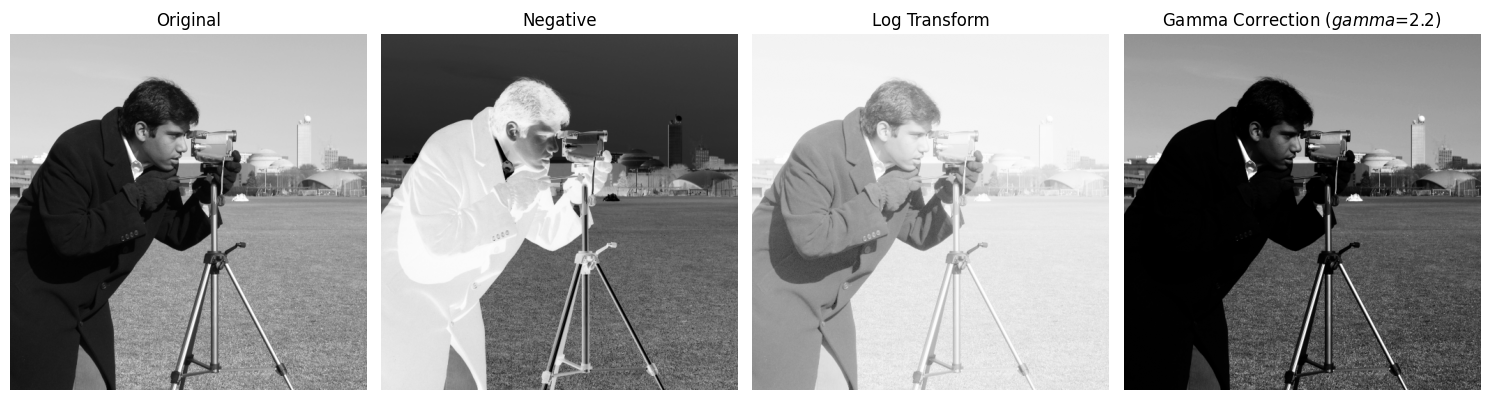

In [136]:
# Plotting the Intensity Transformations

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(negative_img_np, cmap='gray')
plt.title('Negative')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transform')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(gamma_img, cmap='gray')
plt.title(f'Gamma Correction ($gamma$={gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()

